# 0. Зависимости

In [1]:
import sys, os

if not os.path.exists("/content/covid19-xai"):
    os.system("git clone https://github.com/dmikib/covid19-xai.git /content/covid19-xai")

sys.path.insert(0, "/content/covid19-xai/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from utils import (compute_metrics, metrics_table, smooth_series, mark_omicron,
                   train_test_split_temporal, add_lag_features,
                   plot_forecast, plot_metrics_bar, set_plot_style)

set_plot_style()

FIGURES = "/content/covid19-xai/results/figures"
METRICS = "/content/covid19-xai/results/metrics"
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(METRICS, exist_ok=True)

TEST_DAYS = 31
print("Зависимости загружены")

Зависимости загружены


# 1. Загрузка данных

In [2]:
DATA_PROCESSED = "/content/covid19-xai/data/processed"

df = pd.read_csv(f"{DATA_PROCESSED}/dataset_final.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

TARGET = "new_cases_smoothed"

train_df, test_df = train_test_split_temporal(df, TEST_DAYS)
y_train     = train_df[TARGET].values
y_test      = test_df[TARGET].values
dates_test  = test_df["date"].values

print(f"Train: {len(train_df)} дней ({train_df['date'].min().date()} — {train_df['date'].max().date()})")
print(f"Test:  {len(test_df)} дней  ({test_df['date'].min().date()} — {test_df['date'].max().date()})")
print(f"Target: {TARGET}, пропуски: {df[TARGET].isna().sum()}")

Train: 622 дней (2021-01-01 — 2022-09-14)
Test:  31 дней  (2022-09-15 — 2022-10-15)
Target: new_cases_smoothed, пропуски: 0


# 2. Naive baseline

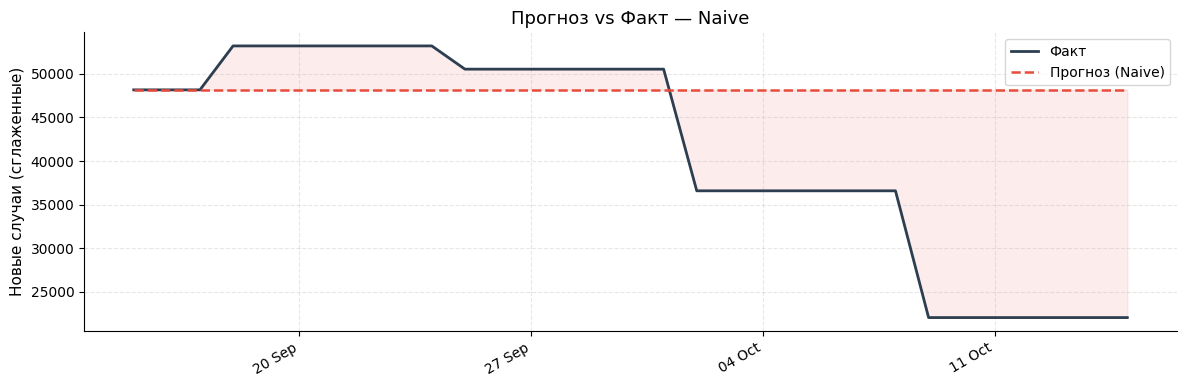

             Model     RMSE      MAE  MAPE      R2
Naive (last value) 13836.23 10190.32 37.11 -0.3234


In [3]:
naive_pred = np.full(len(y_test), y_train[-1])
m_naive = compute_metrics(y_test, naive_pred, "Naive (last value)")
plot_forecast(dates_test, y_test, naive_pred, "Naive",
              save_path=f"{FIGURES}/02_naive.png")
plt.show()
print(m_naive.to_string(index=False))

# 3. Moving Average (MA-7)

In [4]:
ma_pred = np.full(len(y_test), np.mean(y_train[-7:]))
m_ma = compute_metrics(y_test, ma_pred, "Moving Average (7d)")
print(m_ma.to_string(index=False))

              Model     RMSE      MAE  MAPE     R2
Moving Average (7d) 13441.75 10271.42 36.64 -0.249


4. ARIMA(7,1,2)

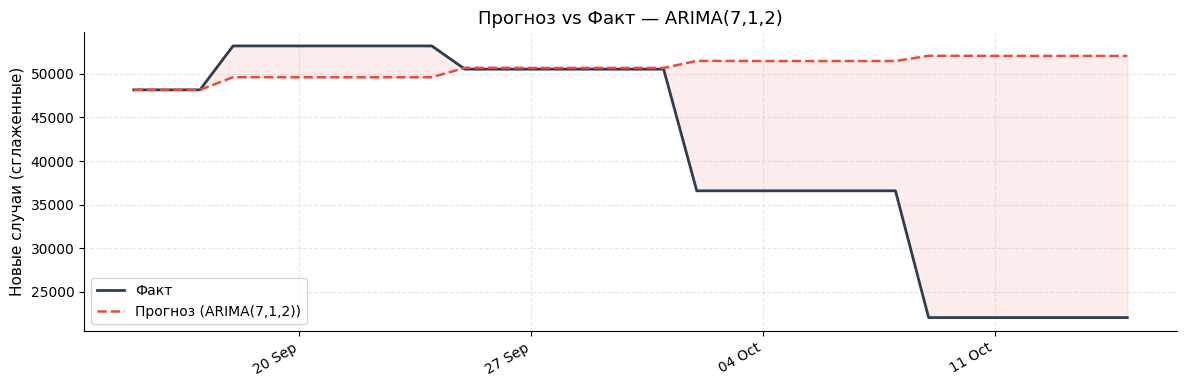

       Model     RMSE      MAE  MAPE      R2
ARIMA(7,1,2) 16018.14 10987.22 41.54 -0.7737


In [5]:
arima_model = ARIMA(y_train, order=(7, 1, 2))
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(steps=TEST_DAYS)
m_arima = compute_metrics(y_test, arima_pred, "ARIMA(7,1,2)")
plot_forecast(dates_test, y_test, arima_pred, "ARIMA(7,1,2)",
              save_path=f"{FIGURES}/02_arima.png")
plt.show()
print(m_arima.to_string(index=False))

5. XGBoost Univariate (лаги 1–14)

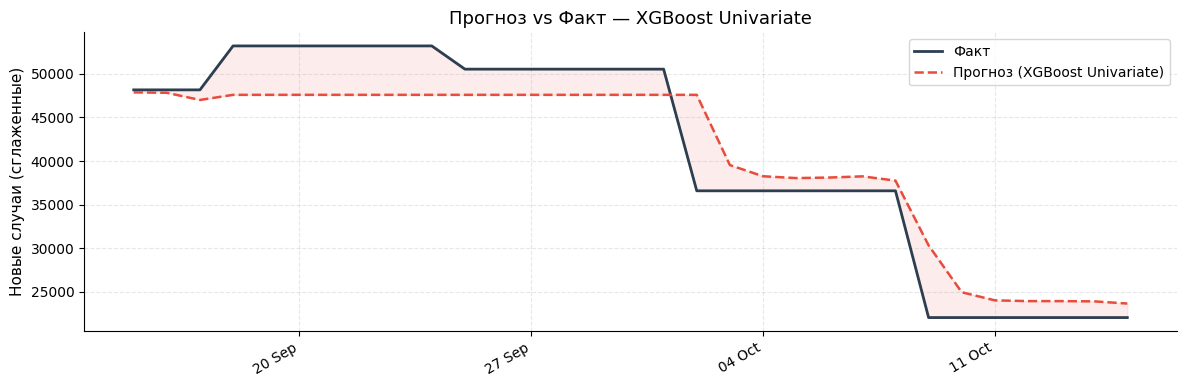

             Model    RMSE     MAE  MAPE     R2
XGBoost Univariate 4089.66 3341.23   8.7 0.8844


In [6]:
LAG_COLS = [f"{TARGET}_lag{i}" for i in range(1, 15)]
df_lag   = add_lag_features(df, TARGET, lags=range(1, 15)).dropna()

train_lag = df_lag.iloc[:-TEST_DAYS]
test_lag  = df_lag.iloc[-TEST_DAYS:]

xgb_uni = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, verbosity=0)
xgb_uni.fit(train_lag[LAG_COLS].values, train_lag[TARGET].values)
xgb_uni_pred = xgb_uni.predict(test_lag[LAG_COLS].values)

m_xgb_uni = compute_metrics(test_lag[TARGET].values, xgb_uni_pred, "XGBoost Univariate")
plot_forecast(test_lag["date"].values, test_lag[TARGET].values, xgb_uni_pred,
              "XGBoost Univariate", save_path=f"{FIGURES}/02_xgb_univariate.png")
plt.show()
print(m_xgb_uni.to_string(index=False))

6. Итоговая таблица

BASELINE СРАВНЕНИЕ
              Model     RMSE      MAE  MAPE      R2
 Naive (last value) 13836.23 10190.32 37.11 -0.3234
Moving Average (7d) 13441.75 10271.42 36.64 -0.2490
       ARIMA(7,1,2) 16018.14 10987.22 41.54 -0.7737
 XGBoost Univariate  4089.66  3341.23  8.70  0.8844


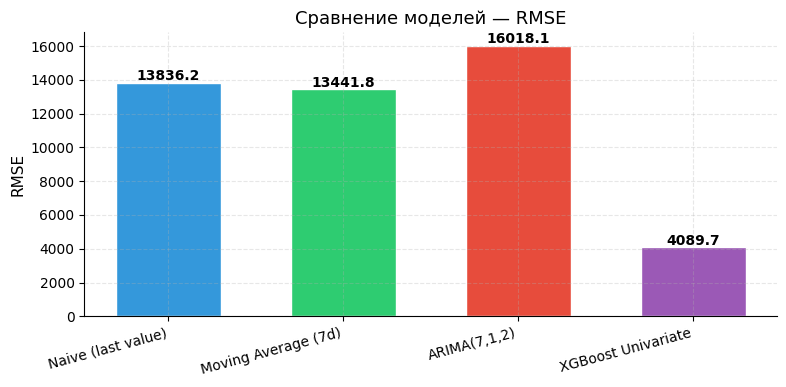

In [7]:
all_metrics = metrics_table([m_naive, m_ma, m_arima, m_xgb_uni])
all_metrics.to_csv(f"{METRICS}/02_baseline_metrics.csv", index=False)
print("BASELINE СРАВНЕНИЕ")
print(all_metrics.to_string(index=False))
plot_metrics_bar(all_metrics, "RMSE", save_path=f"{FIGURES}/02_baseline_rmse.png")
plt.show()

## 7. Вывод

Тестовый период (15 сен - 15 окт 2022) характеризуется резким спадом заболеваемости
с ~50 000 до ~23 000 случаев/день - это структурный перелом, сложный для univariate моделей.

Результаты:
- Naive и Moving Average: RMSE ~13 500-13 800, R² < 0 — хуже среднего предсказания.
  Обе модели фиксируют последнее значение и не видят нисходящий тренд.
- ARIMA(7,1,2): худший результат (RMSE 16 018, R² = -0.77) — экстраполирует тренд
  вверх, тогда как факт падает.
- XGBoost Univariate: RMSE 4 090, R² = 0.88 - лаги 1-14 позволяют уловить
  направление тренда. Значительно превосходит статистические baseline модели.

Вывод: даже univariate XGBoost на лагах целевой переменной существенно лучше
классических методов на данном периоде. Это устанавливает нижнюю планку качества.
Добавление внешних признаков (погода, мобильность, Google Trends) в мультивариантной
постановке должно дать дополнительный прирост.

**Следующий шаг** → `03_multivariate.ipynb`

In [8]:
from google.colab import files

files.download("/content/covid19-xai/notebooks/02_baseline.ipynb")
files.download("/content/covid19-xai/results/figures/02_naive.png")
files.download("/content/covid19-xai/results/figures/02_arima.png")
files.download("/content/covid19-xai/results/figures/02_xgb_univariate.png")
files.download("/content/covid19-xai/results/figures/02_baseline_rmse.png")
files.download("/content/covid19-xai/results/metrics/02_baseline_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>